# Airbnb Price Prediction

#### Info


In [160]:
import pandas as pd
df = pd.read_csv('Data/train.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36195 entries, 0 to 36194
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          36195 non-null  int64 
 1   realSum                     36195 non-null  object
 2   room_type                   36195 non-null  object
 3   room_shared                 36195 non-null  object
 4   room_private                36195 non-null  object
 5   person_capacity             36195 non-null  object
 6   host_is_superhost           36195 non-null  object
 7   multi                       36195 non-null  object
 8   biz                         36195 non-null  object
 9   cleanliness_rating          36195 non-null  object
 10  guest_satisfaction_overall  36195 non-null  object
 11  bedrooms                    36195 non-null  object
 12  dist                        36195 non-null  object
 13  metro_dist                  36195 non-null  ob

C:\Users\Mayco\AppData\Local\Temp\ipykernel_2764\873271734.py:2: DtypeWarning: Columns (1,3,4,5,6,7,8,9,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/train.csv')


In [161]:
df

,id,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,lng,lat,city,day_type
0,1,210.3658537,Entire home/apt,FALSE,FALSE,2,FALSE,0,1,9,91,0,0.541021778,0.42791926,-9.13395,38.71038,lisbon,weekday
1,2,176.1817209,Private room,FALSE,TRUE,2,FALSE,1,0,9,89,1,3.032839151,0.343492056,2.14165,41.37011,barcelona,weekday
2,3,142.0541405,Private room,FALSE,TRUE,2,TRUE,0,0,10,98,1,11.90971188,6.710908979,0.00475,51.44025,london,weekend
3,4,428.7445242,Entire home/apt,FALSE,FALSE,4,FALSE,0,0,9,94,0,4.158389765,0.145570338,2.30179,48.87297,paris,weekend
4,5,220.2798022,Entire home/apt,FALSE,FALSE,6,TRUE,0,1,10,93,2,1.302189968,0.369474779,23.72468,37.96746,athens,weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36190,36191,819.507876,Entire home/apt,False,False,2,False,0,0,10,98,1,1.045763,0.103595,2.3403,48.85198,paris,weekend
36191,36192,1437.91156,Entire home/apt,False,False,6,False,0,1,9,96,3,0.438281,0.111253,4.89923,52.37203,amsterdam,weekday
36192,36193,297.373358,Entire home/apt,False,False,6,False,0,1,9,93,3,0.350367,0.351252,-9.136,38.711,lisbon,weekend
36193,36194,405.72123,Entire home/apt,False,False,4,False,1,0,9,97,2,6.287702,0.260901,13.42734,52.46729,berlin,weekend


### EDA: Duplicados, Valores Faltantes, Outliers.

In [162]:
cols_a_convertir = [
    "realSum", "person_capacity", "cleanliness_rating",
    "guest_satisfaction_overall", "bedrooms", "dist", "metro_dist", "lng", "lat"
]

for col in cols_a_convertir:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [163]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36195 entries, 0 to 36194
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          36195 non-null  int64  
 1   realSum                     36194 non-null  float64
 2   room_type                   36195 non-null  object 
 3   room_shared                 36195 non-null  object 
 4   room_private                36195 non-null  object 
 5   person_capacity             36194 non-null  float64
 6   host_is_superhost           36195 non-null  object 
 7   multi                       36195 non-null  object 
 8   biz                         36195 non-null  object 
 9   cleanliness_rating          36194 non-null  float64
 10  guest_satisfaction_overall  36194 non-null  float64
 11  bedrooms                    36194 non-null  float64
 12  dist                        36194 non-null  float64
 13  metro_dist                  361

In [164]:
print(df.describe())

                 id       realSum  person_capacity  cleanliness_rating  \
count  36195.000000  36194.000000     36194.000000        36194.000000   
mean   18098.000000    279.386846         3.159391            9.389761   
std    10448.740833    328.042369         1.294476            0.954591   
min        1.000000     39.009259         2.000000            2.000000   
25%     9049.500000    148.645200         2.000000            9.000000   
50%    18098.000000    211.230343         3.000000           10.000000   
75%    27146.500000    319.051960         4.000000           10.000000   
max    36195.000000  16445.614690         6.000000           10.000000   

       guest_satisfaction_overall      bedrooms          dist    metro_dist  \
count                36194.000000  36194.000000  36194.000000  36194.000000   
mean                    92.614218      1.157595      3.183128      0.676998   
std                      8.917921      0.631141      2.383785      0.848039   
min              

In [165]:
df.drop_duplicates(inplace=True)

In [166]:
missing_values = df.isnull().sum()
print(missing_values)

id                            0
realSum                       1
room_type                     0
room_shared                   0
room_private                  0
person_capacity               1
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            1
guest_satisfaction_overall    1
bedrooms                      1
dist                          1
metro_dist                    1
lng                           1
lat                           1
city                          0
day_type                      0
dtype: int64


In [167]:
# Rellenar con la mediana de cada columna
df = df.fillna(df.median(numeric_only=True))


In [168]:
missing_values = df.isnull().sum()
print(missing_values)

id                            0
realSum                       0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
lng                           0
lat                           0
city                          0
day_type                      0
dtype: int64


In [169]:
import seaborn as sns
import matplotlib.pyplot as plt


In [170]:
def boxplot_features(df, features):

    for feature in features:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[feature])
        plt.title(f"Boxplot de {feature}")
        plt.xlabel(feature)
        plt.show()

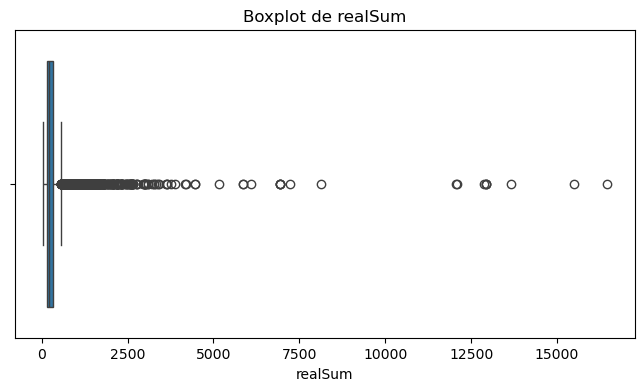

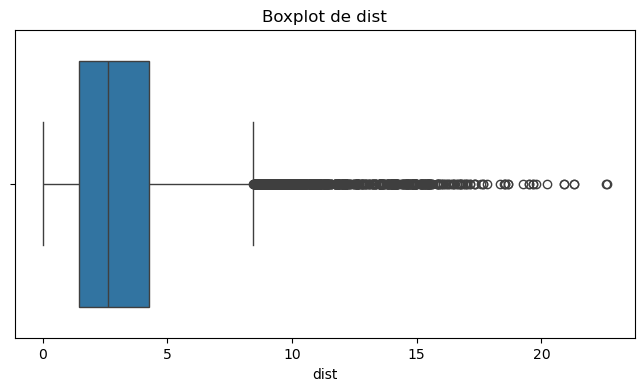

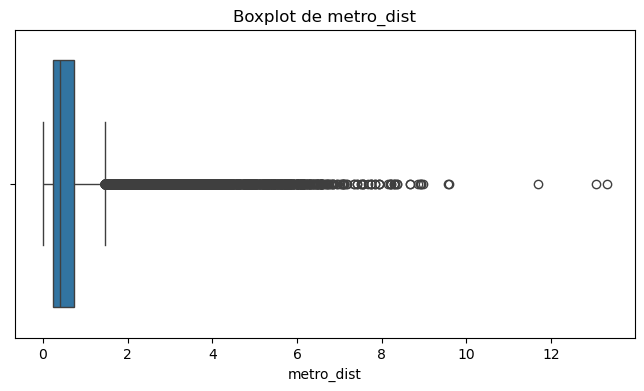

In [171]:
# Lista de features numéricas a analizar
features_numericas = [
    'realSum', 'dist', 'metro_dist'
]

# Llamada función
boxplot_features(df, features_numericas)

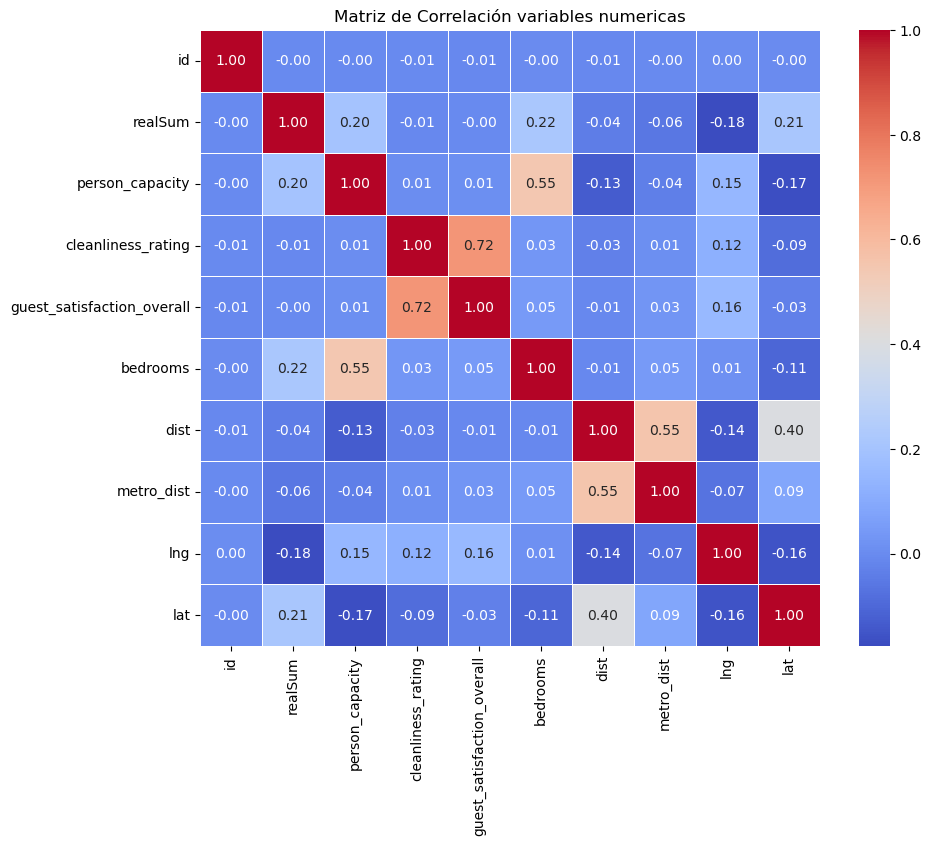

In [172]:
# Seleccionar solo las columnas numéricas
numeric_df = df.select_dtypes(include='number')

# matriz de correlación
corr_matrix = numeric_df.corr()

# Visualizarla con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación variables numericas")
plt.show()


In [173]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Aplicar a realSum
price_outliers = detect_outliers_iqr(df, 'realSum')
print(f"Número de outliers en precios: {len(price_outliers)}")
print(" ")
print("Outliers mas caros:")
print(price_outliers.sort_values('realSum', ascending=False).head(10)[['city', 'room_type', 'bedrooms', 'realSum']])

Número de outliers en precios: 2538
 
Outliers mas caros:
            city        room_type  bedrooms       realSum
23550      paris  Entire home/apt       1.0  16445.614690
33232     london  Entire home/apt       3.0  15499.894160
19195     vienna     Private room       1.0  13656.358830
15993     vienna  Entire home/apt       1.0  12942.991380
30958     london  Entire home/apt       2.0  12937.275100
879       london     Private room       1.0  12929.513860
10086     london     Private room       1.0  12886.239090
16731     london     Private room       3.0  12076.953830
27742     london     Private room       3.0  12048.731160
3418   amsterdam  Entire home/apt       3.0   8130.668104


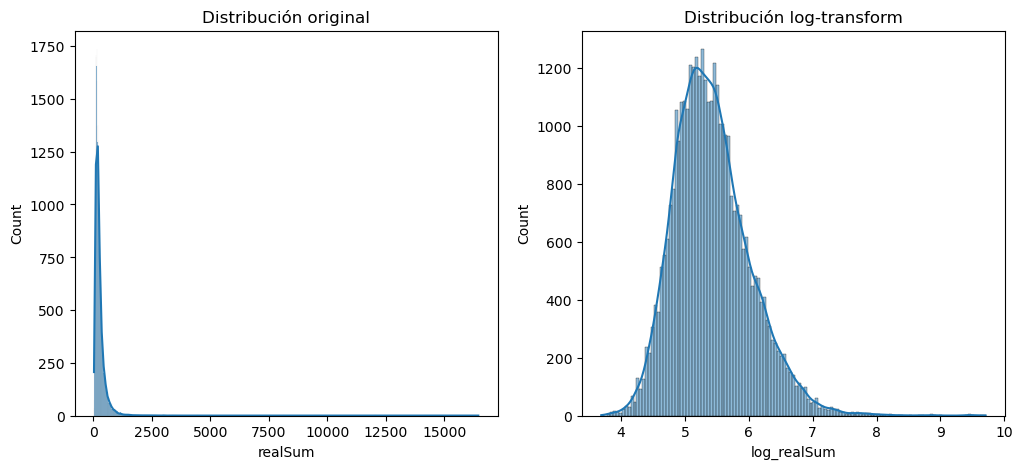

In [174]:
import numpy as np

# Aplicar log-transform a realSum
df['log_realSum'] = np.log1p(df['realSum'])

# Visualizar comparación
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['realSum'], kde=True)
plt.title('Distribución original')
plt.subplot(1, 2, 2)
sns.histplot(df['log_realSum'], kde=True)
plt.title('Distribución log-transform')
plt.show()

In [175]:
#Winsorizacion de outliers de realSum:

# Definir percentiles máximos por ciudad y tipo
max_percentiles = {
    'london': {'Entire home/apt': 0.97, 'Private room': 0.95, 'Shared room': 0.95},
    'paris': {'Entire home/apt': 0.96, 'Private room': 0.94, 'Shared room': 0.94},
    # ... definir para otras ciudades
}

df['realSum_treated'] = df['realSum'].copy()

for city, room_types in max_percentiles.items():
    for room_type, percentile in room_types.items():
        mask = (df['city'] == city) & (df['room_type'] == room_type)
        threshold = df.loc[mask, 'realSum'].quantile(percentile)
        df.loc[mask & (df['realSum'] > threshold), 'realSum_treated'] = threshold

In [176]:
#Winsorizacion de outliers de dist y metro_dist

from scipy.stats.mstats import winsorize

def winsorize_by_city(df, variable, limits=(0.05, 0.05)):
    """
    Winsoriza una variable considerando diferencias por ciudad
    """
    df[f'{variable}_win'] = df[variable].copy()
    
    for city in df['city'].unique():
        city_mask = df['city'] == city
        df.loc[city_mask, f'{variable}_win'] = winsorize(
            df.loc[city_mask, variable], 
            limits=limits
        )
    
    return df
# Aplicar winsorización considerando diferencias por ciudad
data = winsorize_by_city(df, 'dist', limits=(0.05, 0.05))
data = winsorize_by_city(df, 'metro_dist', limits=(0.05, 0.05))

# Para variables de distancia, podríamos ser más conservadores con el límite superior
# ya que las distancias muy grandes podrían ser errores
df['dist_win'] = winsorize(df['dist'], limits=(0.05, 0.10))
df['metro_dist_win'] = winsorize(df['metro_dist'], limits=(0.05, 0.10))

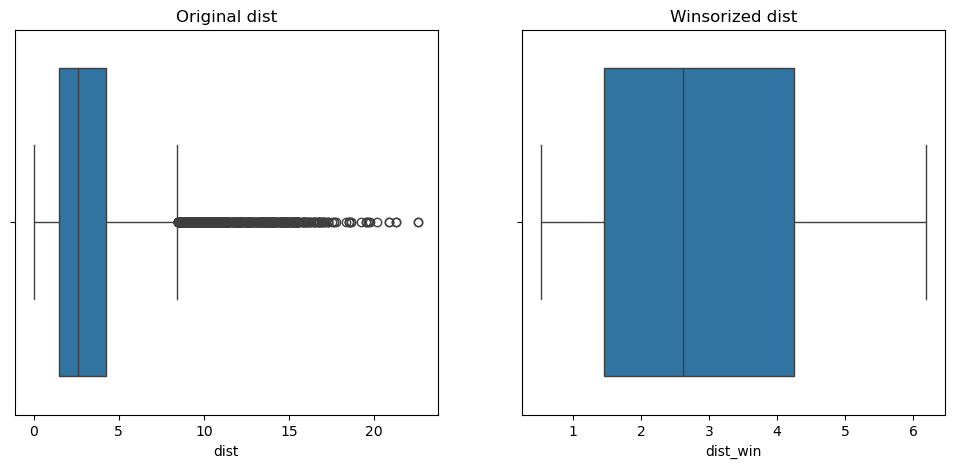

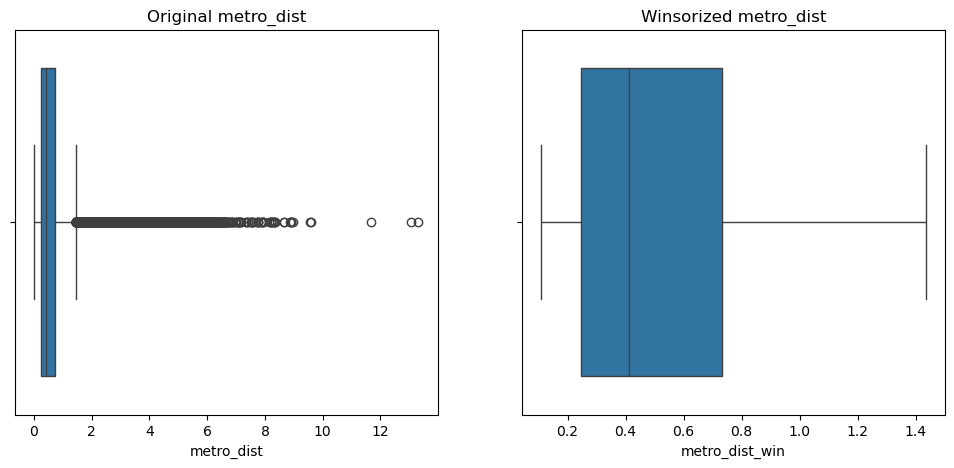

In [177]:
# Comparación antes/después
def compare_before_after(df, var):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[var])
    plt.title(f'Original {var}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[f'{var}_win'])
    plt.title(f'Winsorized {var}')
    plt.show()
    

compare_before_after(data, 'dist')
compare_before_after(data, 'metro_dist')

In [178]:
df

,id,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,dist,metro_dist,lng,lat,city,day_type,log_realSum,realSum_treated,dist_win,metro_dist_win
0,1,210.365854,Entire home/apt,FALSE,FALSE,2.0,FALSE,0,1,9.0,...,0.541022,0.427919,-9.13395,38.71038,lisbon,weekday,5.353591,210.365854,0.541022,0.427919
1,2,176.181721,Private room,FALSE,TRUE,2.0,FALSE,1,0,9.0,...,3.032839,0.343492,2.14165,41.37011,barcelona,weekday,5.177176,176.181721,3.032839,0.343492
2,3,142.054140,Private room,FALSE,TRUE,2.0,TRUE,0,0,10.0,...,11.909712,6.710909,0.00475,51.44025,london,weekend,4.963223,142.054140,6.182339,1.434108
3,4,428.744524,Entire home/apt,FALSE,FALSE,4.0,FALSE,0,0,9.0,...,4.158390,0.145570,2.30179,48.87297,paris,weekend,6.063191,428.744524,4.158390,0.145570
4,5,220.279802,Entire home/apt,FALSE,FALSE,6.0,TRUE,0,1,10.0,...,1.302190,0.369475,23.72468,37.96746,athens,weekend,5.399428,220.279802,1.302190,0.369475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36190,36191,819.507876,Entire home/apt,False,False,2.0,False,0,0,10.0,...,1.045763,0.103595,2.34030,48.85198,paris,weekend,6.709924,819.507876,1.045763,0.109482
36191,36192,1437.911560,Entire home/apt,False,False,6.0,False,0,1,9.0,...,0.438281,0.111253,4.89923,52.37203,amsterdam,weekday,7.271642,1437.911560,0.532537,0.111253
36192,36193,297.373358,Entire home/apt,False,False,6.0,False,0,1,9.0,...,0.350367,0.351252,-9.13600,38.71100,lisbon,weekend,5.698346,297.373358,0.532537,0.351252
36193,36194,405.721230,Entire home/apt,False,False,4.0,False,1,0,9.0,...,6.287702,0.260901,13.42734,52.46729,berlin,weekend,6.008128,405.721230,6.182339,0.260901


### Feature engeneering

In [179]:

# Distancia total (hipotenusa)
df['total_dist'] = np.sqrt(df['dist_win']**2 + df['metro_dist_win']**2)
    
# Interacción entre capacidad y habitaciones
df['capacity_per_room'] = df['person_capacity'] / (df['bedrooms'] + 1e-6)
    



### Preprocesamiento: Escalado y normalizacion

In [180]:
# Aplicar One-Hot Encoding a categoricos
cols_to_encode = ['room_type', 'room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz', 'day_type', 'city']
df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Convertir las columnas con valores booleanos (True/False) a enteros (1/0)
df_encoded = df_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

print(df_encoded.head())

C:\Users\Mayco\AppData\Local\Temp\ipykernel_2764\2330702925.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_encoded = df_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


   id     realSum  person_capacity  cleanliness_rating  \
0   1  210.365854              2.0                 9.0   
1   2  176.181721              2.0                 9.0   
2   3  142.054140              2.0                10.0   
3   4  428.744524              4.0                 9.0   
4   5  220.279802              6.0                10.0   

   guest_satisfaction_overall  bedrooms       dist  metro_dist       lng  \
0                        91.0       0.0   0.541022    0.427919  -9.13395   
1                        89.0       1.0   3.032839    0.343492   2.14165   
2                        98.0       1.0  11.909712    6.710909   0.00475   
3                        94.0       0.0   4.158390    0.145570   2.30179   
4                        93.0       2.0   1.302190    0.369475  23.72468   

        lat  ...  city_athens  city_barcelona  city_berlin  city_budapest  \
0  38.71038  ...            0               0            0              0   
1  41.37011  ...            0           

In [181]:
# Normalizacion de datos numericos

from sklearn.preprocessing import MinMaxScaler

numeric_columns = ['person_capacity', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'lng', 'lat', 'total_dist', 'capacity_per_room']

# Creamos el escalador
scaler = MinMaxScaler()

# Aplicar la normalización a las variables numéricas
df_encoded[numeric_columns] = scaler.fit_transform(df_encoded[numeric_columns])

print(df_encoded[numeric_columns].head())

   person_capacity  cleanliness_rating  guest_satisfaction_overall  bedrooms  \
0              0.0               0.875                      0.8875       0.0   
1              0.0               0.875                      0.8625       0.1   
2              0.0               1.000                      0.9750       0.1   
3              0.5               0.875                      0.9250       0.0   
4              1.0               1.000                      0.9125       0.2   

       dist  metro_dist       lng       lat  total_dist  capacity_per_room  
0  0.023271    0.031906  0.002788  0.051563    0.025181       3.333333e-01  
1  0.133516    0.025563  0.344349  0.232640    0.432299       2.999997e-07  
2  0.526257    0.503925  0.279618  0.918224    1.000000       2.999997e-07  
3  0.183314    0.010694  0.349200  0.743441    0.623363       6.666667e-01  
4  0.056947    0.027515  0.998142  0.000984    0.139573       4.666664e-07  


In [182]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['id', 'realSum', 'log_realSum', 'realSum_treated', 'dist', 'metro_dist'])  # Datos preprocesados
y = df_encoded['realSum_treated']  # Variable objetivo, winsorizada


# División 70-30 con shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    shuffle=True
)


# Alinear columnas (por si get_dummies crea diferente número de columnas en train y test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (25336, 45), Prueba: (10859, 45)


In [183]:
# Eliminar columnas duplicadas
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]


### Modelos

In [184]:
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0),
    #"Decision Tree": DecisionTreeRegressor(random_state=42),
    #"AdaBoost": AdaBoostRegressor(random_state=42)
}
# Entrenar y evaluar cada modelo
results = {}

for name, model in models.items():
    # Entrenar modelo
    model.fit(X_train, y_train)
    
    # Predecir en conjunto de prueba
    y_pred = model.predict(X_test)
    
    # Calcular MAE
    mse = mean_squared_error(y_test, y_pred)
    results[name] = mse

print("\nComparativa de MSE en orden (baseline):")
for name, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {mae:.2f}")


Comparativa de MSE en orden (baseline):
Random Forest: 21007.68
XGBoost: 21802.78
CatBoost: 26181.37


#### Random Forest

In [185]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np

# Definir los espacios de búsqueda para cada modelo
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'n_jobs': [-1]
}

param_dist_xgb = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),  # Entre 0.6 y 1.0
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

In [186]:
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (25336, 43)
Forma de y_train: (25336,)


#### Random Forest: Grid Search

In [187]:
# Crear el modelo base
#rf = RandomForestRegressor(random_state=42)

# Configurar GridSearchCV
#rf_grid = GridSearchCV(estimator=rf,
                      #param_grid=param_grid_rf,
                      #cv=5,
                      #scoring='neg_mean_squared_error',
                      #n_jobs=-1,
                      #verbose=2)

# Ejecutar la búsqueda
#rf_grid.fit(X_train, y_train)

# Resultados
#print("\nMejores parámetros para Random Forest:")
#print(rf_grid.best_params_)
#print(f"Mejor MSE: {-rf_grid.best_score_:.2f}")

# Evaluar en el conjunto de prueba
#rf_best = rf_grid.best_estimator_
#y_pred_rf = rf_best.predict(X_test)
#mse_rf = mean_squared_error(y_test, y_pred_rf)
#print(f"MSE en test (Random Forest optimizado): {mse_rf:.2f}")

#### XGBoost: Randomized Search

In [188]:
# Crear el modelo base
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Configurar RandomizedSearchCV
xgb_random = RandomizedSearchCV(estimator=xgb,
                               param_distributions=param_dist_xgb,
                               n_iter=50,  # Número de combinaciones a probar
                               cv=5,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1,
                               verbose=2,
                               random_state=42)

# Ejecutar la búsqueda
xgb_random.fit(X_train, y_train)

# Resultados
print("\nMejores parámetros para XGBoost:")
print(xgb_random.best_params_)
print(f"Mejor MSE: {-xgb_random.best_score_:.2f}")

# Evaluar en el conjunto de prueba
xgb_best = xgb_random.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f"MSE en test (XGBoost optimizado): {mse_xgb:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores parámetros para XGBoost:
{'colsample_bytree': np.float64(0.6020739451095947), 'gamma': np.float64(0.31394720747431804), 'learning_rate': np.float64(0.06828218605361266), 'max_depth': 8, 'n_estimators': 243, 'reg_alpha': np.float64(0.050768531039396936), 'reg_lambda': np.float64(0.8866171489506599), 'subsample': np.float64(0.6110467087494819)}
Mejor MSE: 27892.75
MSE en test (XGBoost optimizado): 19263.24


In [200]:
features = X_train.columns.tolist()
import joblib
joblib.dump(features, 'model_features.pkl')


['model_features.pkl']

#### Resultados Finales

In [189]:
# Crear tabla comparativa
results_comparison = pd.DataFrame({
    'Modelo': ['Random Forest Base',  
               'XGBoost Base', 'XGBoost Optimizado'], #'Random Forest Optimizado',
    'MSE Test': [
        results['Random Forest'],
        #mse_rf,
        results['XGBoost'],
        mse_xgb
    ]
})

print("\nComparación final:")
print(results_comparison.sort_values('MSE Test'))


Comparación final:
               Modelo      MSE Test
2  XGBoost Optimizado  19263.235846
0  Random Forest Base  21007.684755
1        XGBoost Base  21802.779378


In [190]:
import joblib

joblib.dump(xgb_best, 'modelo_xgboost.pkl')

['modelo_xgboost.pkl']

In [191]:
xgb_best.save_model('modelo_xgb.json')


### Dataset de prueba

In [192]:
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import xgboost as xgb
import joblib

data = pd.read_csv('Data/test.csv')
 
model = joblib.load('modelo_xgboost.pkl')


#### Preprocesamiento

In [194]:
cols_a_convertir = [
    "person_capacity", "cleanliness_rating",
    "guest_satisfaction_overall", "bedrooms", "dist", "metro_dist", "lng", "lat"
]

for col in cols_a_convertir:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data.drop_duplicates(inplace=True)
missing_values = data.isnull().sum()
data = data.fillna(data.median(numeric_only=True))


In [195]:
from scipy.stats.mstats import winsorize

def winsorize_by_city(data, variable, limits=(0.05, 0.05)):
    """
    Winsoriza una variable considerando diferencias por ciudad
    """
    data[f'{variable}_win'] = data[variable].copy()
    
    for city in data['city'].unique():
        city_mask = data['city'] == city
        data.loc[city_mask, f'{variable}_win'] = winsorize(
            data.loc[city_mask, variable], 
            limits=limits
        )
    
    return data
# Aplicar winsorización considerando diferencias por ciudad
df = winsorize_by_city(data, 'dist', limits=(0.05, 0.05))
df = winsorize_by_city(data, 'metro_dist', limits=(0.05, 0.05))

# Para variables de distancia, podríamos ser más conservadores con el límite superior
# ya que las distancias muy grandes podrían ser errores
data['dist_win'] = winsorize(data['dist'], limits=(0.05, 0.10))
data['metro_dist_win'] = winsorize(data['metro_dist'], limits=(0.05, 0.10))

#### Feature Engineering

In [196]:
# Distancia total (hipotenusa)
data['total_dist'] = np.sqrt(data['dist_win']**2 + data['metro_dist_win']**2)
    
# Interacción entre capacidad y habitaciones
data['capacity_per_room'] = data['person_capacity'] / (data['bedrooms'] + 1e-6)
    


#### Escalado y normalizado

In [197]:
cols_to_encode = ['room_type', 'room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz', 'day_type', 'city']
data_encoded = pd.get_dummies(data, columns=cols_to_encode, drop_first=True)

# Convertir las columnas con valores booleanos (True/False) a enteros (1/0)
data_encoded = data_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

print(data_encoded.head())

C:\Users\Mayco\AppData\Local\Temp\ipykernel_2764\2087834584.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_encoded = data_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


      id  person_capacity  cleanliness_rating  guest_satisfaction_overall  \
0  36196                2                  10                          98   
1  36197                4                  10                         100   
2  36198                4                   9                          94   
3  36199                4                  10                          97   
4  36200                2                   8                          80   

   bedrooms      dist  metro_dist      lng       lat  dist_win  ...  \
0         1  5.216136    0.152300  2.28512  48.87109  5.216136  ...   
1         2  2.422495    0.259421  2.32800  48.87100  2.422495  ...   
2         2  1.738184    0.377649  4.89285  52.35761  1.738184  ...   
3         1  1.351006    0.572999 -9.14402  38.72405  1.351006  ...   
4         0  3.655290    0.318106 -0.08255  51.52542  3.655290  ...   

   day_type_weekend  city_athens  city_barcelona  city_berlin  city_budapest  \
0                 0           

In [198]:
# Normalizacion de datos numericos

from sklearn.preprocessing import MinMaxScaler

numeric_columns = ['person_capacity', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'lng', 'lat', 'total_dist', 'capacity_per_room']

# Creamos el escalador
scaler = MinMaxScaler()

# Aplicar la normalización a las variables numéricas
data_encoded[numeric_columns] = scaler.fit_transform(data_encoded[numeric_columns])

print(data_encoded[numeric_columns].head())

   person_capacity  cleanliness_rating  guest_satisfaction_overall  bedrooms  \
0              0.0               1.000                      0.9750  0.111111   
1              0.5               1.000                      1.0000  0.222222   
2              0.5               0.875                      0.9250  0.222222   
3              0.5               1.000                      0.9625  0.111111   
4              0.0               0.750                      0.7500  0.000000   

       dist  metro_dist       lng       lat  total_dist  capacity_per_room  
0  0.204935    0.010511  0.348702  0.744425    0.792804       2.962960e-07  
1  0.094258    0.018017  0.350000  0.744419    0.322453       2.962961e-07  
2  0.067147    0.026301  0.427694  0.982167    0.211272       2.962961e-07  
3  0.051808    0.039989  0.002494  0.052509    0.158651       6.296290e-07  
4  0.143098    0.022129  0.276981  0.925421    0.530874       3.333333e-01  


#### predicciones

In [201]:
features = joblib.load('model_features.pkl')
data_encoded = data_encoded.reindex(columns=features, fill_value=0)
predictions = xgb_best.predict(data_encoded)


In [ ]:
submission = pd.DataFrame({
    'id': data['id'],  # Asumiendo que test.csv tiene columna 'id'
    'realSum': predictions    # Ajusta el nombre según lo que pida Kaggle
})

submission.to_csv('submission_xgboost_optimized.csv', index=False)

print("¡Archivo de submission creado con éxito!")
print("\nMuestra del archivo:")
print(submission.head())

¡Archivo de submission creado con éxito!

Muestra del archivo:
      id     realSum
0  36196  344.380432
1  36197  511.556305
2  36198  854.435669
3  36199  244.684067
4  36200  298.842529
